# Examine PACE OCI $R_{rs}$

In [32]:
# imports
from importlib import reload
import os
import numpy as np

from matplotlib import pyplot as plt

import xarray
import pandas

from ocpy.pace import io as pace_io
from ocpy.utils import plotting
from ocpy.utils import coords as ocpy_coords
from ocpy.water import scattering

# BING
from bing import evaluate
from bing.parameters import standard
from bing.models import utils as model_utils
from bing.priors import priors as bing_priors
from bing.fitting import inference as bing_inf
from bing.fitting import chisq_fit

# Locals
from grab_pace_granules import load_from_json
import fitting as m_fitting
import grab_pace_granules


# Load up

In [6]:
match_file = 'matched_argo_bgc_profiles_bbp.csv'
# Load up Argo profiles, already matched to PACE
matched = pandas.read_csv(match_file)

# Load up PACE granules
granules, pace = load_from_json('PACE_50clouds.json')


In [7]:
matched.head()

,cruise,filename,profile,lat,lon,time,solar_angle,pace_ids,closest_id,closest_file,closest_dist_km,closest_time,Bnw,Bnw_std,Bnw_lsig,Bnw_hsig,beta,aph
0,1902368,1902368QC.nc,13,56.348,-147.356,2024-07-09 04:35:00.000002048+00:00,13.134825,PACE_OCI_L2_AOP_PACE_OCI.20240708T202028.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240708T202028.L2.OC...,PACE_OCI.20240708T202028.L2.OC_AOP.V3_0.nc,671.392674,2024-07-08 20:22:57.500000+00:00,0.001467,0.000453,0.000075,0.000077,1.930553,0.041115
1,1902369,1902369QC.nc,4,45.006,-133.357,2024-05-09 22:07:00.000001536+00:00,58.276589,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI.20240510T203409.L2.OC_AOP.V3_0.nc,0.620598,2024-05-10 20:36:38.500000+00:00,0.000501,0.000057,0.000037,0.000039,1.874987,0.005746
2,1902369,1902369QC.nc,5,45.020,-133.356,2024-05-10 09:02:59.999999488+00:00,-27.116450,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI.20240510T203409.L2.OC_AOP.V3_0.nc,0.579841,2024-05-10 20:36:38.500000+00:00,0.000475,0.000124,0.000037,0.000037,1.868712,0.006338
3,1902369,1902369QC.nc,6,45.020,-133.354,2024-05-10 19:52:59.999998464+00:00,60.421381,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI.20240510T203409.L2.OC_AOP.V3_0.nc,0.709744,2024-05-10 20:36:38.500000+00:00,0.000475,0.000126,0.000037,0.000037,1.868712,0.006338
4,1902369,1902369QC.nc,7,45.038,-133.348,2024-05-11 08:18:59.999995904+00:00,-26.535430,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI.20240510T203409.L2.OC_AOP.V3_0.nc,1.471472,2024-05-10 20:36:38.500000+00:00,0.000603,0.000123,0.000040,0.000043,1.817395,0.006617


# Try one

In [8]:
imt = 0
imatched = matched.iloc[imt]
imatched

cruise                                                       1902368
filename                                                1902368QC.nc
profile                                                           13
lat                                                           56.348
lon                                                         -147.356
time                             2024-07-09 04:35:00.000002048+00:00
solar_angle                                                13.134825
pace_ids           PACE_OCI_L2_AOP_PACE_OCI.20240708T202028.L2.OC...
closest_id         PACE_OCI_L2_AOP_PACE_OCI.20240708T202028.L2.OC...
closest_file              PACE_OCI.20240708T202028.L2.OC_AOP.V3_0.nc
closest_dist_km                                           671.392674
closest_time                        2024-07-08 20:22:57.500000+00:00
Bnw                                                         0.001467
Bnw_std                                                     0.000453
Bnw_lsig                          

In [18]:
fit_file = os.path.join(os.getenv('OS_COLOR'), 'Biomass', 'Fits',
                     f'Argo_{imatched.cruise}_{imatched.profile:03d}_fits.npz')
assert os.path.isfile(fit_file)

## Load

In [21]:
fit = np.load(fit_file)
list(fit.keys())

['chains',
 'LM',
 'wave',
 'Rrs',
 'Rrs_sig',
 'Rrs_idx',
 'lon',
 'lat',
 'dist',
 'med',
 'p14',
 'p86',
 'model_names']

In [22]:
fit['Rrs'].shape

(10, 136)

# Plot one

In [24]:
fit['wave'].shape

(10, 136)

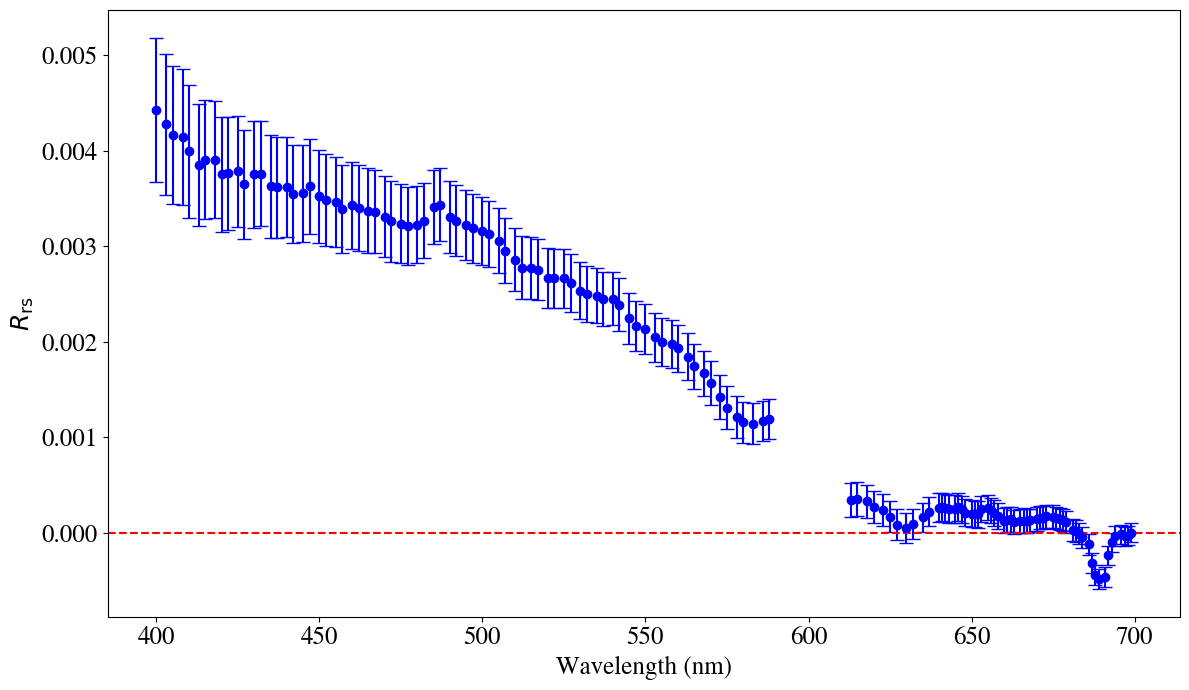

In [29]:
fig = plt.figure(figsize=(12,7))
ax = plt.gca()
#
clr = 'b'
ax.errorbar(fit['wave'][0], fit['Rrs'][0], yerr=fit['Rrs_sig'][0],
                color=clr,  fmt='o', capsize=5) 
#
#ax.set_yscale('log')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{\rm rs}$')
#
plotting.set_fontsize(ax, 18.)
#
ax.axhline(0., color='r', ls='--')
#
plt.tight_layout()
plt.savefig('Rrs_example.png', dpi=300)
plt.show()

# Fit

Saved: tmpc.png
Error in callback <function _draw_all_if_interactive at 0x79f07f33b6a0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

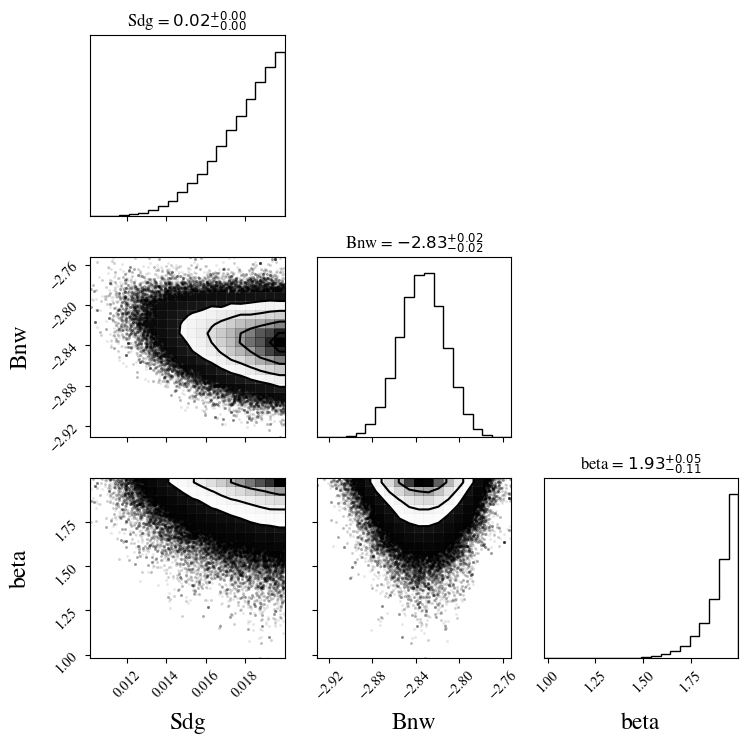

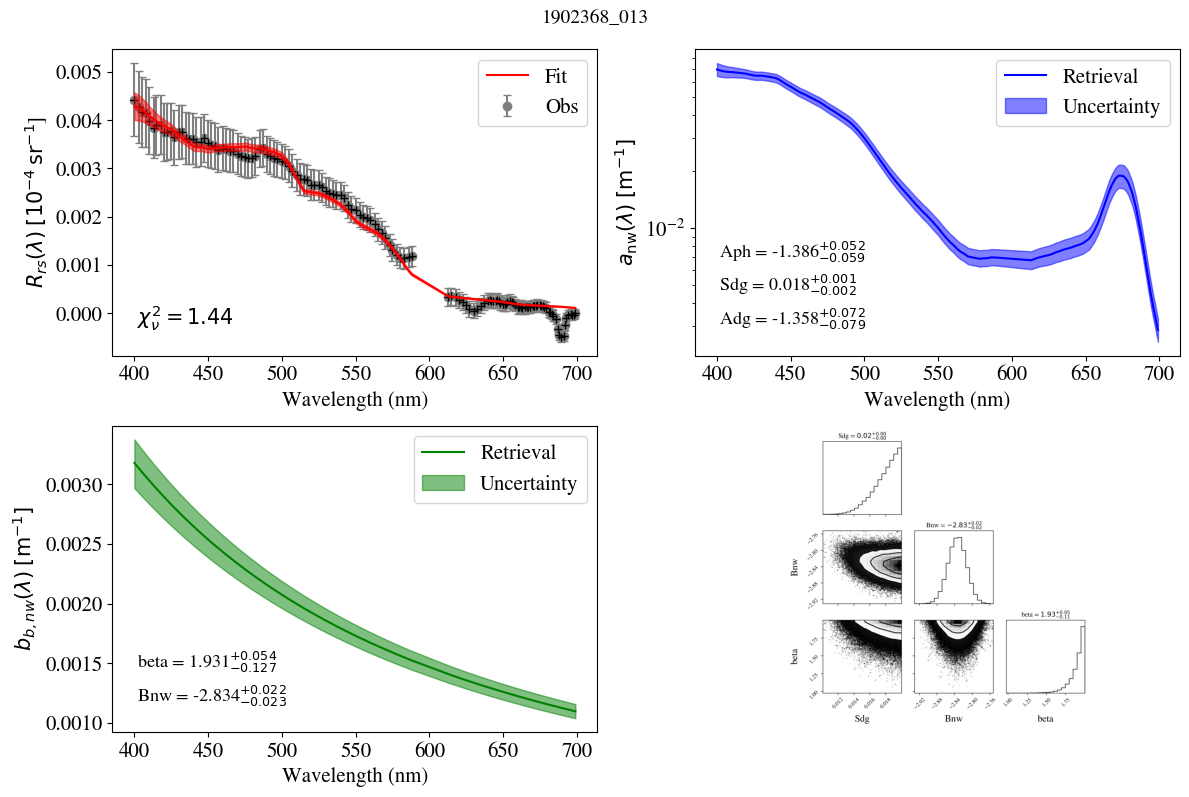

In [34]:
p = standard.expb_pow()
models = model_utils.init(fit['model_names'], fit['wave'][0])
Rrs_obs=dict(wave=fit['wave'][0],  spec=fit['Rrs'][0], var=fit['Rrs_sig'][0]**2)
m_fitting.plot_fit(models, fit['chains'], Rrs_obs,  f'{imatched.cruise}_{imatched.profile:03d}', 
                   show_Rsig=True)#, outfile=plotfile)

# Residuals